In [2]:
import sys
import os

# add project root to Python path
sys.path.append(os.path.abspath(".."))

from src.preprocessing import load_data, clean_data, encode_categorical, scale_features
from src.clustering import find_best_k, run_kmeans
from src.visualization import plot_pca, plot_tsne, plot_cluster_distribution

In [ ]:
df.shape
df.info()



In [ ]:
for col in df_encoded.columns:
    if df_encoded[col].dtype == "object":
        print("PROBLEM COLUMN:", col)
        print(df_encoded[col].unique()[:10])
        print("-"*50)

In [ ]:
df.isnull().sum().sort_values(ascending=False)

In [ ]:
threshold = len(df) * 0.5
df_clean = df.dropna(thresh=threshold, axis=1)

In [ ]:
df_clean.shape

In [ ]:
def clean_data(df):
    df = df.copy()

    numeric_cols = df.select_dtypes(include=["number"]).columns
    categorical_cols = df.select_dtypes(include=["object"]).columns

    # fill numeric columns with median
    for col in numeric_cols:
        df[col] = df[col].fillna(df[col].median())

    # fill categorical columns with mode
    for col in categorical_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].mode()[0])

    return df

In [ ]:
df_clean = clean_data(df_clean)

In [ ]:
df_clean.isnull().sum().sum()

In [ ]:
df_encoded = encode_categorical(df_clean)

In [ ]:
df_scaled, scaler = scale_features(df_encoded)

In [ ]:
def clean_data(df):
    df = df.copy()

    numeric_cols = df.select_dtypes(include=["number"]).columns
    categorical_cols = df.select_dtypes(include=["object"]).columns

    # numeric → median
    for col in numeric_cols:
        df[col] = df[col].fillna(df[col].median())

    # categorical → mode
    for col in categorical_cols:
        df[col] = df[col].fillna(df[col].mode()[0])

    return df

In [17]:
df_clean = clean_data(df)

df_encoded, encoder = encode_categorical(df_clean)

df_encoded = df_encoded.apply(pd.to_numeric, errors="coerce")
df_encoded = df_encoded.fillna(0)

df_scaled, scaler = scale_features(df_encoded)

In [18]:
kmeans = KMeans(n_clusters=3)

In [19]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

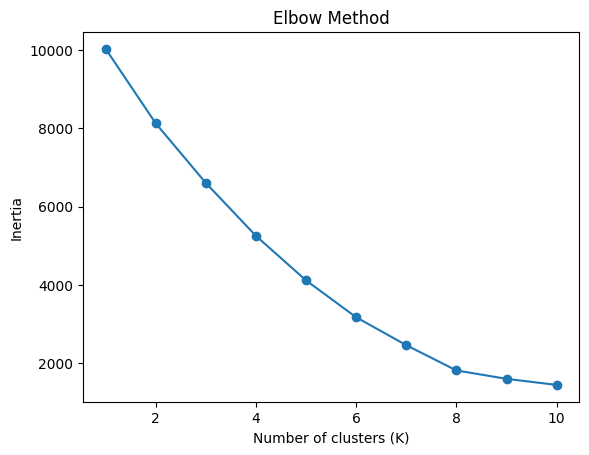

In [22]:
import matplotlib.pyplot as plt

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [23]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

In [24]:
df_result = df_clean.copy()
df_result["Cluster"] = clusters
df_result.head()

,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",...,"If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,What is your gender?,What country do you live in?,What US state or territory do you live in?,What country do you work in?,What US state or territory do you work in?,Which of the following best describes your work position?,Do you work remotely?,Cluster
0,0,26-100,1.0,1.0,Not eligible for coverage / N/A,No,No,No,I don't know,Very easy,...,Not applicable to me,39,Male,United Kingdom,California,United Kingdom,California,Back-end Developer,Sometimes,0
1,0,6-25,1.0,1.0,No,Yes,Yes,Yes,Yes,Somewhat easy,...,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never,0
2,0,6-25,1.0,1.0,No,No,No,No,I don't know,Neither easy nor difficult,...,Not applicable to me,38,Male,United Kingdom,California,United Kingdom,California,Back-end Developer,Always,0
3,1,26-100,1.0,1.0,Yes,No,No,No,I don't know,Somewhat easy,...,Sometimes,43,male,United Kingdom,California,United Kingdom,California,Supervisor/Team Lead,Sometimes,1
4,0,6-25,0.0,1.0,Yes,Yes,No,No,No,Neither easy nor difficult,...,Sometimes,43,Female,United States of America,Illinois,United States of America,Illinois,Executive Leadership|Supervisor/Team Lead|Dev ...,Sometimes,2


In [25]:
df_result["Cluster"].value_counts()

Cluster
0    882
1    288
2    248
3     15
Name: count, dtype: int64

In [26]:
df_result.groupby("Cluster").mean(numeric_only=True)

,Are you self-employed?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?,Do you have previous employers?,Have you ever sought treatment for a mental health issue from a mental health professional?,What is your age?
Cluster,,,,,,,
0,0.000000,1.0,1.0,1.000000,0.892290,0.573696,32.818594
1,0.996528,1.0,1.0,0.645833,0.868056,0.631944,37.798611
2,0.000000,0.0,1.0,1.000000,0.866935,0.576613,35.245968
3,0.000000,0.0,0.0,1.000000,0.800000,0.533333,37.266667


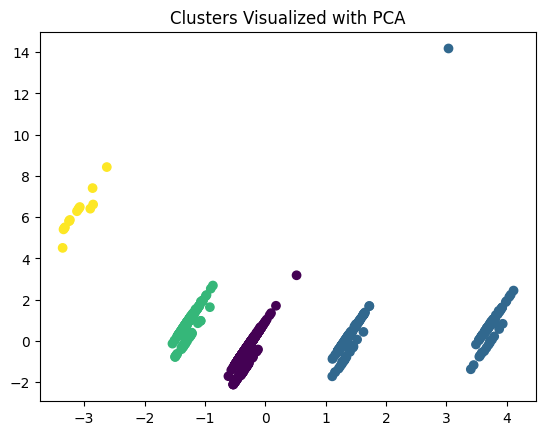

In [27]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(df_scaled)

plt.scatter(reduced[:,0], reduced[:,1], c=clusters)
plt.title("Clusters Visualized with PCA")
plt.show()

In [28]:
cluster_summary = df_result.groupby("Cluster").mean(numeric_only=True)
cluster_summary

,Are you self-employed?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?,Do you have previous employers?,Have you ever sought treatment for a mental health issue from a mental health professional?,What is your age?
Cluster,,,,,,,
0,0.000000,1.0,1.0,1.000000,0.892290,0.573696,32.818594
1,0.996528,1.0,1.0,0.645833,0.868056,0.631944,37.798611
2,0.000000,0.0,1.0,1.000000,0.866935,0.576613,35.245968
3,0.000000,0.0,0.0,1.000000,0.800000,0.533333,37.266667


In [21]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(df_scaled)
    inertia.append(model.inertia_)

In [15]:
print(df_scaled.shape)

(1433, 63)


In [16]:
from sklearn.cluster import KMeans

In [ ]:
for col in df_encoded.columns:
    if df_encoded[col].dtype == "object":
        print(col, df_encoded[col].unique()[:5])

In [ ]:
for col in df_encoded.columns:
    if df_encoded[col].dtype == "object":
        print(col)
        print(df_encoded[col].head())
        print("-"*40)

In [ ]:
df_encoded.select_dtypes(include="object").columns

In [ ]:
import inspect
from src.preprocessing import clean_data

print(inspect.getsource(clean_data))

In [ ]:
import importlib
import src.preprocessing as p

importlib.reload(p)

from src.preprocessing import clean_data

In [ ]:
df_encoded.select_dtypes(include="object").columns

In [ ]:
result = encode_categorical(df_clean)
type(result), len(result)

In [ ]:
def encode_categorical(df):
    df = df.copy()

    for col in df.columns:
        if df[col].dtype == "object" or str(df[col].dtype) == "category":
            df[col] = df[col].astype("category").cat.codes

    return df

In [ ]:
df_encoded = df_encoded.apply(pd.to_numeric, errors="coerce")
df_encoded = df_encoded.fillna(0)

In [ ]:
df_scaled, scaler = scale_features(df_encoded)

In [ ]:
df_encoded.select_dtypes(include="object").columns

In [9]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

df_encoded = df_encoded.copy()

# force convert everything to numeric
df_encoded = df_encoded.apply(pd.to_numeric, errors="coerce")

# fill remaining NaNs created by conversion
df_encoded = df_encoded.fillna(0)

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_encoded)

df_scaled, scaler

(array([[-0.50043611,  0.        ,  0.47411636, ...,  0.        ,
          0.        ,  0.        ],
        [-0.50043611,  0.        ,  0.47411636, ...,  0.        ,
          0.        ,  0.        ],
        [-0.50043611,  0.        ,  0.47411636, ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [-0.50043611,  0.        ,  0.47411636, ...,  0.        ,
          0.        ,  0.        ],
        [-0.50043611,  0.        , -2.10918686, ...,  0.        ,
          0.        ,  0.        ],
        [-0.50043611,  0.        ,  0.47411636, ...,  0.        ,
          0.        ,  0.        ]], shape=(1433, 63)),
 StandardScaler())

In [ ]:
df_encoded.dtypes

In [ ]:
type(df_encoded)

In [3]:
df = load_data("../data/mental-heath-in-tech-2016_20161114.csv")
df.head()

,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",...,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,What is your gender?,What country do you live in?,What US state or territory do you live in?,What country do you work in?,What US state or territory do you work in?,Which of the following best describes your work position?,Do you work remotely?
0,0,26-100,1.0,NaN,Not eligible for coverage / N/A,NaN,No,No,I don't know,Very easy,...,Not applicable to me,Not applicable to me,39,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Sometimes
1,0,6-25,1.0,NaN,No,Yes,Yes,Yes,Yes,Somewhat easy,...,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never
2,0,6-25,1.0,NaN,No,NaN,No,No,I don't know,Neither easy nor difficult,...,Not applicable to me,Not applicable to me,38,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Always
3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Sometimes,Sometimes,43,male,United Kingdom,NaN,United Kingdom,NaN,Supervisor/Team Lead,Sometimes
4,0,6-25,0.0,1.0,Yes,Yes,No,No,No,Neither easy nor difficult,...,Sometimes,Sometimes,43,Female,United States of America,Illinois,United States of America,Illinois,Executive Leadership|Supervisor/Team Lead|Dev ...,Sometimes


In [ ]:
import os

print("CURRENT DIR:", os.getcwd())
print("FILES HERE:", os.listdir("."))
print("DATA EXISTS HERE:", os.path.exists("data"))
print("DATA EXISTS ONE LEVEL UP:", os.path.exists("../data"))

In [ ]:
import os

for root, dirs, files in os.walk(".."):
    if "mental_health_survey.csv" in files:
        print("FOUND AT:", os.path.join(root, "mental_health_survey.csv"))

In [ ]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if "csv" in file:
            print(os.path.join(root, file))

In [ ]:
import os

for root, dirs, files in os.walk("."):
    print("FOLDER:", root)
    print("FILES:", files)
    print("-" * 40)

In [4]:
df = clean_data(df)
df.head()

,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",...,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,What is your gender?,What country do you live in?,What US state or territory do you live in?,What country do you work in?,What US state or territory do you work in?,Which of the following best describes your work position?,Do you work remotely?
0,0,26-100,1.0,1.0,Not eligible for coverage / N/A,No,No,No,I don't know,Very easy,...,Not applicable to me,Not applicable to me,39,Male,United Kingdom,California,United Kingdom,California,Back-end Developer,Sometimes
1,0,6-25,1.0,1.0,No,Yes,Yes,Yes,Yes,Somewhat easy,...,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never
2,0,6-25,1.0,1.0,No,No,No,No,I don't know,Neither easy nor difficult,...,Not applicable to me,Not applicable to me,38,Male,United Kingdom,California,United Kingdom,California,Back-end Developer,Always
3,1,26-100,1.0,1.0,Yes,No,No,No,I don't know,Somewhat easy,...,Sometimes,Sometimes,43,male,United Kingdom,California,United Kingdom,California,Supervisor/Team Lead,Sometimes
4,0,6-25,0.0,1.0,Yes,Yes,No,No,No,Neither easy nor difficult,...,Sometimes,Sometimes,43,Female,United States of America,Illinois,United States of America,Illinois,Executive Leadership|Supervisor/Team Lead|Dev ...,Sometimes


In [ ]:
df.isnull().sum().sum()

In [ ]:
df_encoded, encoders = encode_categorical(df)
df_encoded.head()

In [ ]:
scaled_data, scaler = scale_features(df_encoded)

In [ ]:
best_k, scores = find_best_k(scaled_data)
print("Best K:", best_k)

In [ ]:
model, labels = run_kmeans(scaled_data, best_k)

In [ ]:
plot_pca(scaled_data, labels)
plot_tsne(scaled_data, labels)
plot_cluster_distribution(labels)